<a href="https://colab.research.google.com/github/sk27110/MMK/blob/HW2/HW2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.utils import resample
from tqdm import tqdm

Грузим данные


In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


Посмотрим, что скачали

In [18]:
data = pd.read_csv(path + "/diabetes.csv")

In [19]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [21]:
data.isna().sum().sum()

np.int64(0)

Данные в порядке. Разделяем, нормализуем

In [22]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Теперь обучим все модели на данных и посчитаем метрики. Будем сохранять результаты

In [62]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "NaiveBayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

report_dict = {}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    report = classification_report(y_test, y_pred, output_dict=True)
    report_dict[name] = report

In [45]:
results

{'Logistic Regression': 0.7142857142857143,
 'SVM': 0.7532467532467533,
 'Random Forest': 0.7467532467532467,
 'Gradient Boosting': 0.7532467532467533,
 'Naive Bayes': 0.7077922077922078,
 'KNN': 0.7012987012987013}

Применим методы уменьшения размерности и посмотрим, как разделяются данные

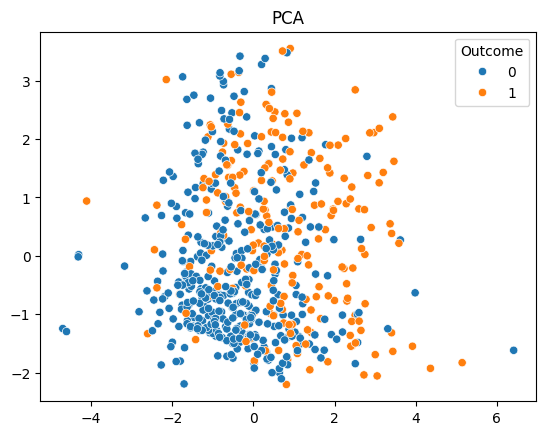

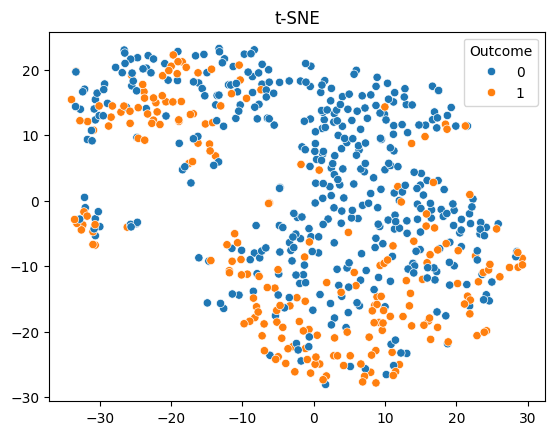

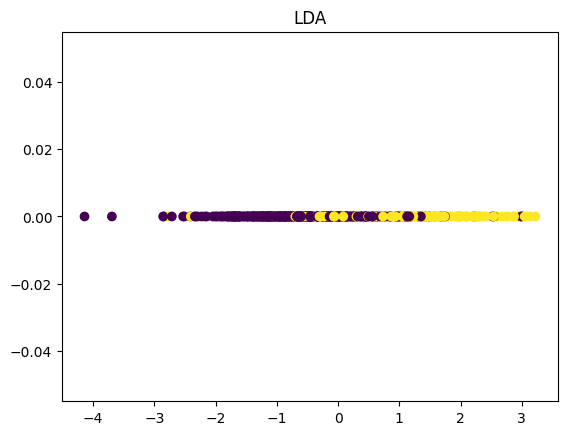

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
plt.figure()
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train)
plt.title("PCA")
plt.show()


tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_scaled)
plt.figure()
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_train)
plt.title("t-SNE")
plt.show()


lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_train_scaled, y_train)
plt.figure()
plt.scatter(X_lda, np.zeros_like(X_lda), c=y_train)
plt.title("LDA")
plt.show()

Создадим данные с пониженной размерностью. У PCA поставим 5 компонент, надеемся сохранить как можно больше информации

In [68]:
pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

In [30]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "NaiveBayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

Функция для бутстрепинга

In [36]:
def bootstrap_evaluation(model, X, y, iterations=250):

    scores = []

    for _ in tqdm(range(iterations)):

        X_sample, y_sample = resample(X, y)

        X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
            X_sample, y_sample, test_size=0.2
        )

        model.fit(X_train_b, y_train_b)

        y_pred = model.predict(X_test_b)

        acc = accuracy_score(y_test_b, y_pred)

        scores.append(acc)

    return np.mean(scores), np.std(scores)

In [37]:
datasets = {
    "Original": (X_train_scaled, y_train),
    "PCA": (X_train_pca, y_train),
    "LDA": (X_train_lda, y_train)
}

Обучаем, считаем

In [38]:
import pandas as pd

results_bootstrap = []

for dataset_name, (X_data, y_data) in datasets.items():

    for model_name, model in models.items():

        mean_acc, std_acc = bootstrap_evaluation(
            model, X_data, y_data, iterations=250
        )

        results_bootstrap.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Bootstrap Mean Accuracy": mean_acc,
            "Bootstrap Std": std_acc
        })

        print(dataset_name, model_name, mean_acc, std_acc)

100%|██████████| 250/250 [00:06<00:00, 38.85it/s]


Original LogisticRegression 0.7826991869918699 0.03623318840645904


100%|██████████| 250/250 [00:06<00:00, 41.34it/s]


Original SVM 0.807089430894309 0.03654561164423782


100%|██████████| 250/250 [00:48<00:00,  5.15it/s]


...

LDA GradientBoosting 0.8343089430894308 0.03436592193807277


100%|██████████| 250/250 [00:00<00:00, 408.87it/s]


LDA NaiveBayes 0.7904390243902439 0.03757278524794581


100%|██████████| 250/250 [00:00<00:00, 292.36it/s]

LDA KNN 0.7928130081300813 0.04063881460738616


In [52]:
results_df = pd.DataFrame(results_bootstrap)
print(results_df)

     Dataset               Model  Bootstrap Mean Accuracy  Bootstrap Std
0   Original  LogisticRegression                 0.782699       0.036233
1   Original                 SVM                 0.807089       0.036546
2   Original        RandomForest                 0.888228       0.031442
3   Original    GradientBoosting                 0.864260       0.032556
4   Original          NaiveBayes                 0.766179       0.041791
5   Original                 KNN                 0.779154       0.043619
6        PCA  LogisticRegression                 0.748293       0.039226
7        PCA                 SVM                 0.775935       0.040921
8        PCA        RandomForest                 0.873984       0.029108
9        PCA    GradientBoosting                 0.851610       0.033941
10       PCA          NaiveBayes                 0.745919       0.042802
11       PCA                 KNN                 0.752715       0.041483
12       LDA  LogisticRegression                 0.

Объединяем все в одну таблицу

In [53]:
acc_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Test Accuracy"]
)

orig = results_df[results_df["Dataset"] == "Original"]
pca = results_df[results_df["Dataset"] == "PCA"]
lda = results_df[results_df["Dataset"] == "LDA"]

orig = orig[["Model", "Bootstrap Mean Accuracy", "Bootstrap Std"]]
orig.columns = ["Model", "Mean Original", "Std Original"]

pca = pca[["Model", "Bootstrap Mean Accuracy", "Bootstrap Std"]]
pca.columns = ["Model", "Mean PCA", "Std PCA"]

lda = lda[["Model", "Bootstrap Mean Accuracy", "Bootstrap Std"]]
lda.columns = ["Model", "Mean LDA", "Std LDA"]

final_df = acc_df.merge(orig, on="Model")
final_df = final_df.merge(pca, on="Model")
final_df = final_df.merge(lda, on="Model")

In [55]:
final_df

,Model,Test Accuracy,Mean Original,Std Original,Mean PCA,Std PCA,Mean LDA,Std LDA
0,LogisticRegression,0.714286,0.782699,0.036233,0.748293,0.039226,0.788488,0.031697
1,SVM,0.753247,0.807089,0.036546,0.775935,0.040921,0.788683,0.037624
2,RandomForest,0.753247,0.888228,0.031442,0.873984,0.029108,0.863740,0.033234
3,GradientBoosting,0.753247,0.864260,0.032556,0.851610,0.033941,0.834309,0.034366
4,NaiveBayes,0.707792,0.766179,0.041791,0.745919,0.042802,0.790439,0.037573
5,KNN,0.701299,0.779154,0.043619,0.752715,0.041483,0.792813,0.040639


Подберем лучшие параметры для SVM

In [60]:
param_dist = {
    "C": np.logspace(-3, 3, 50),
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear", "poly"]
}

svm = SVC(probability=True)

random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

best_svm = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

{'kernel': 'linear', 'gamma': 'scale', 'C': np.float64(0.15998587196060574)}
0.7785419165667067


In [59]:
y_pred_svm = best_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm))

test_acc_svm = accuracy_score(y_test, y_pred_svm)
print(test_acc_svm)

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

0.7142857142857143


###Отчет

In [66]:
for name, report in report_dict.items():
    print("\n", "="*40)
    print(f"{name} Classification Report")
    print("="*40)
    report_text = classification_report(y_test, models[name].predict(X_test_scaled))
    print(report_text)


LogisticRegression Classification Report
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


SVM Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


RandomForest Classification Report
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       100
           1       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71

In [61]:
final_df

,Model,Test Accuracy,Mean Original,Std Original,Mean PCA,Std PCA,Mean LDA,Std LDA
0,LogisticRegression,0.714286,0.782699,0.036233,0.748293,0.039226,0.788488,0.031697
1,SVM,0.753247,0.807089,0.036546,0.775935,0.040921,0.788683,0.037624
2,RandomForest,0.753247,0.888228,0.031442,0.873984,0.029108,0.863740,0.033234
3,GradientBoosting,0.753247,0.864260,0.032556,0.851610,0.033941,0.834309,0.034366
4,NaiveBayes,0.707792,0.766179,0.041791,0.745919,0.042802,0.790439,0.037573
5,KNN,0.701299,0.779154,0.043619,0.752715,0.041483,0.792813,0.040639


In [67]:
print("Лучшие параметры:", random_search.best_params_)
print("Лучший результат:", random_search.best_score_)
print("Результат на тесте:", test_acc_svm)

Лучшие параметры: {'kernel': 'linear', 'gamma': 'scale', 'C': np.float64(0.15998587196060574)}
Лучший результат: 0.7785419165667067
Результат на тесте: 0.7142857142857143


### Выводы

Лучшие результаты показали RandomForest и GradientBoosting. Их результаты лучшие без бутстрэппинга и сильно лучше результатов всех остальных моделей при бутстрэппинге.

Метод PCA всегда уменьшал точность модели.
Метод LDA уменьшал точность RF, GB и SVM, но поднял точность остальных моделей. Возможно, это связано с тем, что метод LDA убрал шум и сделал классы хорошо разделимыми, что сильно влияет на остальные методы.